# Piloto por planta — ¿Dónde empezar el rollout?

Pregunta de gestión: **qué planta debe pilotar Bonsai primero**, cuánto valor captura, qué exige la migración y qué evidencia autoriza el despliegue total.

La demanda por planta **no** es valor: una planta de alto volumen puede ya tener buena utilización de pallet, exigir muchos cambios de caja o generar write-offs caros.

**Anclas**
- Actual: `outputs/tables/00_baseline_solution.csv` + costo oficial ops
- Propuesto: **Mark17 / Bajo protocolo** 3 mm (`outputs/mark17/mark17_from_minbox.csv`) — portafolio demand-free evaluado bajo demanda conocida (score **+9.57638**)
- Sensibilidad: Mark16 Best demand-aware (`04_mark16_best_+10.11098.csv`) — ¿cambia el ranking de piloto?

**Paleta** — Principal `#5CAC31` · Gray `#706F6F` · Verde oscuro `#3B7434` · Light gray `#DADADA`


In [1]:
from pathlib import Path
import sys
from IPython.display import HTML, display

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

_candidates = [Path.cwd(), Path.cwd().parent, Path("..").resolve()]
ROOT = next(p for p in _candidates if (p / "data" / "raw" / "operaciones_planta.csv").exists())
sys.path.insert(0, str(ROOT / "src"))

from evaluate import SUBMISSION_COLS
from mark16 import costo_actual_oficial, score_publico
from settings import PLANTAS
from plant_rollout import (
    evaluar_kaggle,
    metricas_por_planta,
    migration_crosswalk,
    rollout_all_subsets,
    greedy_wave_sequence,
    pareto_mask,
    box_key_frame,
)

GREEN = "#5CAC31"
GRAY = "#706F6F"
GREEN_DARK = "#3B7434"
LIGHT_GRAY = "#DADADA"

PLANT_LABELS = {
    "buenos_aires": "Buenos Aires",
    "curitiba": "Curitiba",
    "santiago": "Santiago",
    "monterrey": "Monterrey",
    "bakersfield": "Bakersfield",
}
PLANT_ORDER = ["curitiba", "santiago", "buenos_aires", "bakersfield", "monterrey"]

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": LIGHT_GRAY,
    "axes.labelcolor": GRAY,
    "axes.titlecolor": GREEN_DARK,
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.color": GRAY,
    "ytick.color": GRAY,
    "text.color": GRAY,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.grid": False,
})


def style_axes(ax, ylabel=None):
    ax.spines["bottom"].set_color(LIGHT_GRAY)
    ax.tick_params(length=0)
    if ylabel:
        ax.set_ylabel(ylabel, color=GRAY)
    ax.yaxis.grid(True, color=LIGHT_GRAY, linewidth=0.8)
    ax.set_axisbelow(True)


def fmt_es(x, nd=0):
    s = f"{x:,.{nd}f}"
    return s.replace(",", "X").replace(".", ",").replace("X", ".")


def fmt_usd(x):
    return f"USD {fmt_es(x, 0)}"


FIG_DIR = ROOT / "outputs" / "figures"
TAB_DIR = ROOT / "outputs" / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

ops = pd.read_csv(ROOT / "data/raw/operaciones_planta.csv")
products = pd.read_csv(ROOT / "data/processed/products_truth.csv")
actual = pd.read_csv(ROOT / "outputs/tables/00_baseline_solution.csv")[SUBMISSION_COLS].copy()
proposed = pd.read_csv(ROOT / "outputs/mark17/mark17_from_minbox.csv")[SUBMISSION_COLS].copy()
mark16_sens = pd.read_csv(ROOT / "outputs/tables/04_mark16_best_+10.11098.csv")[SUBMISSION_COLS].copy()

for df in (ops, products, actual, proposed, mark16_sens):
    df["codigo_producto"] = df["codigo_producto"].astype(str).str.strip()

COSTO_BASELINE = costo_actual_oficial(ops)
eval_act = evaluar_kaggle(actual, ops)
eval_prop = evaluar_kaggle(proposed, ops)
SCORE = score_publico(eval_prop["total"], COSTO_BASELINE)
AHORRO_FULL = COSTO_BASELINE - eval_prop["total"]

m_act = metricas_por_planta(eval_act, ops_oficial=ops)
m_prop = metricas_por_planta(eval_prop)

assert abs(sum(m_act[p]["costo_total"] for p in PLANTAS) - COSTO_BASELINE) < 1.0
assert abs(SCORE - 9.57638) < 1e-4, SCORE

print(f"ROOT = {ROOT}")
print(f"Actual (oficial): USD {COSTO_BASELINE:,.2f}")
print(
    f"Bajo protocolo (Mark17): USD {eval_prop['total']:,.2f}  "
    f"pack=${eval_prop['packaging']:,.0f}  flete=${eval_prop['flete']:,.0f}  tipos={eval_prop['n_tipos']}"
)
print(f"Ahorro programa:  USD {AHORRO_FULL:,.2f}  |  score = {SCORE:+.5f}")


ROOT = /home/lorenn/Desktop/Universidad/Competencia-AlixPartners
Actual (oficial): USD 209,235,093.94
Bajo protocolo (Mark17): USD 189,197,949.24  pack=$27,019,449  flete=$162,178,500  tipos=41
Ahorro programa:  USD 20,037,144.70  |  score = +9.57638


## 1. ¿Dónde está el valor?

Descomposición **Actual vs Bajo protocolo (Mark17)** por planta: ahorro anual, mix flete/packaging, pallets eliminados y eficiencia del cambio (ahorro por SKU cambiado / caja nueva).


In [2]:
mig = migration_crosswalk(actual, proposed, ops, products)

rows = []
for p in PLANT_ORDER:
    a, b = m_act[p], m_prop[p]
    sav = a["costo_total"] - b["costo_total"]
    sav_flete = a["costo_envio"] - b["costo_envio"]
    sav_pack = a["costo_cajas"] - b["costo_cajas"]
    pal_elim = a["pallets"] - b["pallets"]
    mr = mig.loc[mig["planta"] == p].iloc[0]
    skus_ch = int(mr["skus_changed"])
    new_b = int(mr["box_types_new"])
    rows.append({
        "planta": PLANT_LABELS[p],
        "planta_id": p,
        "current_cost": a["costo_total"],
        "proposed_cost": b["costo_total"],
        "savings": sav,
        "savings_pct": 100.0 * sav / a["costo_total"] if a["costo_total"] else 0.0,
        "freight_savings": sav_flete,
        "pack_savings": sav_pack,
        "freight_share_pct": 100.0 * sav_flete / sav if sav else 0.0,
        "pallets_eliminated": pal_elim,
        "share_programme_pct": 100.0 * sav / AHORRO_FULL if AHORRO_FULL else 0.0,
        "skus_changed": skus_ch,
        "new_boxes": new_b,
        "savings_per_sku_changed": sav / skus_ch if skus_ch else np.nan,
        "savings_per_new_box": sav / new_b if new_b else np.nan,
        "util_actual_pct": a["util_pallet_pct"],
        "util_proposed_pct": b["util_pallet_pct"],
    })

valor = pd.DataFrame(rows)
out_csv = TAB_DIR / "260_valor_por_planta.csv"
valor.to_csv(out_csv, index=False)
print("Guardado:", out_csv.relative_to(ROOT))

css = (
    ".bp-wrap { background:#fff; color:#706F6F; font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',Helvetica,Arial,sans-serif; }"
    ".bp-title { color:#3B7434; font-weight:700; font-size:14px; margin:0 0 4px; }"
    ".bp-sub { color:#706F6F; font-size:11px; margin:0 0 12px; }"
    ".bp-table { border-collapse:collapse; width:100%; font-size:12px; }"
    ".bp-table th { text-transform:uppercase; letter-spacing:0.04em; border-bottom:1px solid #DADADA; padding:6px 8px; text-align:left; color:#3B7434; font-size:10px; }"
    ".bp-table td { border-bottom:1px solid #DADADA; padding:6px 8px; }"
    ".bp-table td.num { text-align:right; font-variant-numeric:tabular-nums; }"
    ".bp-table .delta { color:#5CAC31; font-weight:600; }"
)
trs = []
for _, r in valor.iterrows():
    trs.append(
        f"<tr><td>{r['planta']}</td>"
        f"<td class='num'>{fmt_es(r['current_cost']/1e6,1)}M</td>"
        f"<td class='num'>{fmt_es(r['proposed_cost']/1e6,1)}M</td>"
        f"<td class='num delta'>{fmt_es(r['savings']/1e6,2)}M</td>"
        f"<td class='num'>{r['savings_pct']:.1f}%</td>"
        f"<td class='num'>{r['freight_share_pct']:.0f}%</td>"
        f"<td class='num'>{int(r['skus_changed'])}</td>"
        f"<td class='num'>{int(r['new_boxes'])}</td>"
        f"<td class='num'>{fmt_es(r['savings_per_sku_changed']/1e3,0)}k</td></tr>"
    )
html = (
    f"<style>{css}</style><div class='bp-wrap'>"
    f"<p class='bp-title'>A. Valor por planta — Actual vs Bajo protocolo (Mark17)</p>"
    f"<p class='bp-sub'>Ahorro programa = {fmt_usd(AHORRO_FULL)} ({SCORE:+.2f}%). "
    f"Freight share = % del ahorro de la planta que viene de flete.</p>"
    "<table class='bp-table'><thead><tr>"
    "<th>Plant</th><th>Current</th><th>Proposed</th><th>Savings</th><th>Sav %</th>"
    "<th>Freight share</th><th>SKUs chg</th><th>New boxes</th><th>Sav / SKU chg</th>"
    "</tr></thead><tbody>"
    + "".join(trs)
    + "</tbody></table></div>"
)
display(HTML(html))
display(
    valor[
        ["planta", "savings", "share_programme_pct", "skus_changed", "new_boxes", "savings_per_sku_changed"]
    ].round(2)
)


Guardado: outputs/tables/260_valor_por_planta.csv


Plant,Current,Proposed,Savings,Sav %,Freight share,SKUs chg,New boxes,Sav / SKU chg
Curitiba,"74,9M","67,8M","7,07M",9.4%,84%,214,32,33k
Santiago,"53,1M","46,9M","6,18M",11.6%,86%,173,26,36k
Buenos Aires,"30,4M","28,5M","1,91M",6.3%,74%,134,24,14k
Bakersfield,"29,3M","26,0M","3,33M",11.4%,86%,102,20,33k
Monterrey,"21,6M","20,0M","1,55M",7.2%,89%,89,20,17k


,planta,savings,share_programme_pct,skus_changed,new_boxes,savings_per_sku_changed
0,Curitiba,7067223.33,35.27,214,32,33024.41
1,Santiago,6179123.93,30.84,173,26,35717.48
2,Buenos Aires,1910802.95,9.54,134,24,14259.72
3,Bakersfield,3326896.52,16.60,102,20,32616.63
4,Monterrey,1553097.98,7.75,89,20,17450.54


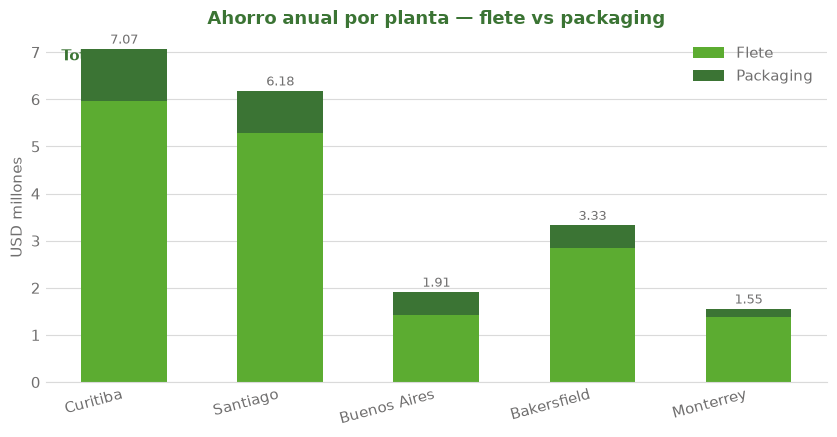

Figura: outputs/figures/260_valor_por_planta.png


In [3]:
fig, ax = plt.subplots(figsize=(8.5, 4.5))
x = np.arange(len(valor))
w = 0.55
flete_m = valor["freight_savings"].to_numpy() / 1e6
pack_m = valor["pack_savings"].to_numpy() / 1e6
ax.bar(x, flete_m, w, label="Flete", color=GREEN)
ax.bar(x, pack_m, w, bottom=flete_m, label="Packaging", color=GREEN_DARK)
for i, r in valor.iterrows():
    tot = (r["freight_savings"] + r["pack_savings"]) / 1e6
    ax.text(i, tot + 0.05, f"{tot:.2f}", ha="center", va="bottom", fontsize=9, color=GRAY)
ax.set_xticks(x)
ax.set_xticklabels(valor["planta"], rotation=15, ha="right")
style_axes(ax, ylabel="USD millones")
ax.set_title("Ahorro anual por planta — flete vs packaging")
ax.legend(frameon=False, loc="upper right")
ax.text(
    0.02, 0.92, f"Total {AHORRO_FULL/1e6:.2f}M", transform=ax.transAxes,
    color=GREEN_DARK, fontweight="bold", fontsize=11,
)
plt.tight_layout()
plt.show()
fig.savefig(FIG_DIR / "260_valor_por_planta.png", dpi=140, bbox_inches="tight", facecolor="white")
print("Figura:", (FIG_DIR / "260_valor_por_planta.png").relative_to(ROOT))


## 2. Overlap y complejidad de migración

Tres lecturas de overlap:

1. **Exacto** — misma geometría exterior + grosor.
2. **Funcional** — el producto sigue cabiendo en la caja Actual (fit volumen/headspace/pallet/compresión).
3. **Ponderado por volumen** — % de unidades anuales que podrían seguir en una caja existente durante la transición.


In [4]:
pack_aff = []
act_i = actual.set_index("codigo_producto")
prop_i = proposed.set_index("codigo_producto")
key_a = box_key_frame(act_i.reset_index())
key_a.index = act_i.index
key_p = box_key_frame(prop_i.reset_index())
key_p.index = prop_i.index
changed = key_a != key_p
ops_i = ops.set_index("codigo_producto")

for p in PLANT_ORDER:
    mask = (ops_i[f"volumen_producto_planta_{p}"] > 0) & changed.reindex(ops_i.index, fill_value=False)
    spend = float(ops_i.loc[mask, f"costo_total_planta_{p}"].sum()) if mask.any() else 0.0
    pack_aff.append(spend)

mig = mig.copy()
mig["pack_spend_affected"] = [
    pack_aff[PLANT_ORDER.index(p)] if p in PLANT_ORDER else 0.0 for p in mig["planta"]
]
mig = mig.set_index("planta").loc[PLANT_ORDER].reset_index()
mig["planta_label"] = mig["planta"].map(PLANT_LABELS)

out_m = TAB_DIR / "260_migracion_por_planta.csv"
mig.to_csv(out_m, index=False)
print("Guardado:", out_m.relative_to(ROOT))

# Global catalogue delta
ka = set(key_a.unique())
kp = set(key_p.unique())
print(
    f"Catálogo global — retained={len(ka & kp)}  retired={len(ka - kp)}  new={len(kp - ka)}"
)

css2 = (
    ".compare-plant-wrap { background:#000; color:#DADADA; font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',Helvetica,Arial,sans-serif; padding:14px; }"
    ".compare-plant-title { color:#5CAC31; font-weight:700; font-size:14px; margin:0 0 4px; }"
    ".compare-plant-sub { color:#9A9A9A; font-size:11px; margin:0 0 12px; }"
    ".compare-plant-table { border-collapse:collapse; width:100%; font-size:12px; }"
    ".compare-plant-table th { text-transform:uppercase; letter-spacing:0.04em; border-bottom:1px solid #2A2A2A; padding:6px 8px; text-align:left; color:#9A9A9A; font-size:10px; }"
    ".compare-plant-table td { border-bottom:1px solid #2A2A2A; padding:6px 8px; }"
    ".compare-plant-table td.num { text-align:right; font-variant-numeric:tabular-nums; }"
    ".compare-plant-table .better { color:#5CAC31; font-weight:600; }"
)
trs = []
for _, r in mig.iterrows():
    trs.append(
        f"<tr><td>{r['planta_label']}</td>"
        f"<td class='num'>{int(r['box_types_retained'])}</td>"
        f"<td class='num'>{int(r['box_types_retired'])}</td>"
        f"<td class='num'>{int(r['box_types_new'])}</td>"
        f"<td class='num'>{int(r['skus_changed'])}</td>"
        f"<td class='num'>{r['pct_vol_exact']:.1f}%</td>"
        f"<td class='num better'>{r['pct_vol_functional']:.1f}%</td>"
        f"<td class='num'>{r['pct_vol_changed']:.1f}%</td>"
        f"<td class='num'>{r['dim_delta_mean_mm']:.1f}</td>"
        f"<td class='num'>{r['dim_delta_max_mm']:.0f}</td></tr>"
    )
html = (
    f"<style>{css2}</style><div class='compare-plant-wrap'>"
    "<p class='compare-plant-title'>B. Complejidad de migración por planta</p>"
    "<p class='compare-plant-sub'>Exact = misma caja. Funcional = producto cabe en caja Actual. "
    "Δ dim = cambio exterior medio/máx (mm).</p>"
    "<table class='compare-plant-table'><thead><tr>"
    "<th>Plant</th><th>Retained</th><th>Retired</th><th>New</th><th>SKUs chg</th>"
    "<th>Vol exact</th><th>Vol functional</th><th>Vol affected</th><th>Δ mean</th><th>Δ max</th>"
    "</tr></thead><tbody>"
    + "".join(trs)
    + "</tbody></table></div>"
)
display(HTML(html))


Guardado: outputs/tables/260_migracion_por_planta.csv
Catálogo global — retained=0  retired=204  new=41


Plant,Retained,Retired,New,SKUs chg,Vol exact,Vol functional,Vol affected,Δ mean,Δ max
Curitiba,0,120,32,214,0.0%,56.2%,100.0%,6.8,28
Santiago,0,102,26,173,0.0%,66.8%,100.0%,6.8,28
Buenos Aires,0,82,24,134,0.0%,94.7%,100.0%,8.1,26
Bakersfield,0,74,20,102,0.0%,60.6%,100.0%,6.2,26
Monterrey,0,52,20,89,0.0%,26.1%,100.0%,7.2,26


## 3. Rollout parcial — ¿hace falta migrar todo junto?

Con **5 plantas** hay **32 subconjuntos**. En cada uno, las plantas migradas usan el portafolio Óptimo y el resto permanece en Actual. Los descuentos siguen siendo **por planta**; el catálogo activo es la **unión** (duplicación temporal).

Esto responde: ¿el caso de ~USD 20M del protocolo se preserva planta-a-planta, o exige despliegue simultáneo?

La curva de valor acumulado en §4 sigue el orden por **mayor impacto global** (Curitiba primero).


In [5]:
# Baseline híbrido = re-eval Kaggle del Actual (consistente con subsets).
# El oficial Kaggle (~USD 129k más alto) se usa solo para el caso de negocio full.
BASE_HYBRID = float(eval_act["total"])
GAP_OFFICIAL_VS_REEVAL = COSTO_BASELINE - BASE_HYBRID

subsets = rollout_all_subsets(actual, proposed, ops, baseline_total=BASE_HYBRID)
full_hybrid = float(subsets.loc[subsets["n_migrated"] == 5, "savings_usd"].iloc[0])
subsets["pct_of_full"] = 100.0 * subsets["savings_usd"] / full_hybrid if full_hybrid else 0.0
subsets["total_cost"] = BASE_HYBRID - subsets["savings_usd"]
subsets["savings_vs_official"] = COSTO_BASELINE - subsets["total_cost"]

sub_out = subsets.drop(columns=["plants_list"]).copy()
sub_out.to_csv(TAB_DIR / "260_rollout_subsets.csv", index=False)
print("Guardado: outputs/tables/260_rollout_subsets.csv")
print(
    f"Gap oficial vs re-eval Actual: USD {GAP_OFFICIAL_VS_REEVAL:,.0f} "
    "(rollout usa re-eval para que empty subset = USD 0)"
)

singles = subsets[subsets["n_migrated"] == 1].copy()
sum_singles = float(singles["savings_usd"].sum())
full_sav = full_hybrid
coupling_gap = full_sav - sum_singles
print(f"Suma ahorros 1-planta: USD {sum_singles:,.0f}")
print(f"Ahorro full (híbrido): USD {full_sav:,.0f}  |  vs oficial: USD {AHORRO_FULL:,.0f}")
print(f"Gap acoplamiento:      USD {coupling_gap:,.0f}  ({100*coupling_gap/full_sav:+.2f}% del full)")

waves_value = greedy_wave_sequence(subsets)
waves_value["plant_label"] = waves_value["plant_added"].map(lambda x: PLANT_LABELS.get(x, x))
print("\nOrden greedy por valor marginal (referencia):")
display(
    waves_value[["wave", "plant_label", "annual_savings", "pct_total_value", "active_box_types", "incremental_value"]].round(2)
)


Guardado: outputs/tables/260_rollout_subsets.csv
Gap oficial vs re-eval Actual: USD -129,178 (rollout usa re-eval para que empty subset = USD 0)
Suma ahorros 1-planta: USD 20,166,323
Ahorro full (híbrido): USD 20,166,323  |  vs oficial: USD 20,037,145
Gap acoplamiento:      USD -0  (-0.00% del full)

Orden greedy por valor marginal (referencia):


,wave,plant_label,annual_savings,pct_total_value,active_box_types,incremental_value
0,0,(none),0.00,0.00,204,0.00
1,1,Curitiba,7067223.33,35.04,207,7067223.33
2,2,Santiago,13321882.14,66.06,161,6254658.81
3,3,Bakersfield,16702422.26,82.82,131,3380540.12
4,4,Buenos Aires,18613225.21,92.30,93,1910802.95
5,5,Monterrey,20166323.19,100.00,41,1553097.98


In [6]:
print("Orden por impacto (curva §4):", " → ".join(
    waves_value.loc[waves_value["wave"] > 0, "plant_label"].tolist()
))


Orden por impacto (curva §4): Curitiba → Santiago → Bakersfield → Buenos Aires → Monterrey


## 4. ¿Cuál es el mejor piloto? — frontera de Pareto

Eje X = **complejidad de migración** (suma de z-scores: SKUs cambiados + cajas nuevas + % volumen *sin* overlap funcional).  
Eje Y = **ahorro anual**.  
Tamaño = packaging spend afectado.  
Sin pesos arbitrarios: solo la frontera Pareto (nadie ofrece más valor con menos complejidad).

> Overlap exacto Actual→Mark17 es tipicamente bajo (reemplazo de diseños). La complejidad operativa usa el complemento del **overlap funcional** (producto que aún cabe en la caja Actual durante la transición).


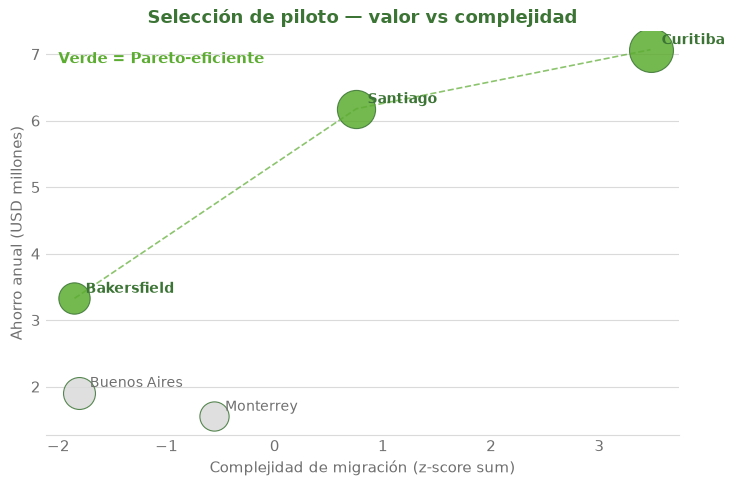

Piloto recomendado (Pareto + complejidad acotada): Santiago
  Ahorro USD 6,179,124 (30.8% del programa) · SKUs chg=173 · new boxes=26 · vol functional overlap=66.8%
Nota: Curitiba lidera valor absoluto; si complejidad alta es aceptable, también es Pareto y es Wave 1 del orden max-valor.


,planta,planta_id,complexity,savings,bubble,pareto,skus_changed,new_boxes,pct_vol_functional,pct_vol_must_move,share_programme_pct
0,Curitiba,curitiba,3.47,7067223.33,10793725.95,True,214,32,56.20,43.80,35.27
1,Santiago,santiago,0.75,6179123.93,7495408.97,True,173,26,66.77,33.23,30.84
2,Buenos Aires,buenos_aires,-1.81,1910802.95,4437284.69,False,134,24,94.70,5.30,9.54
3,Bakersfield,bakersfield,-1.85,3326896.52,4163442.79,True,102,20,60.58,39.42,16.60
4,Monterrey,monterrey,-0.56,1553097.98,3276431.54,False,89,20,26.06,73.94,7.75


Guardado: outputs/tables/260_rollout_waves.csv
Rollout por impacto: Curitiba → Santiago → Bakersfield → Buenos Aires → Monterrey


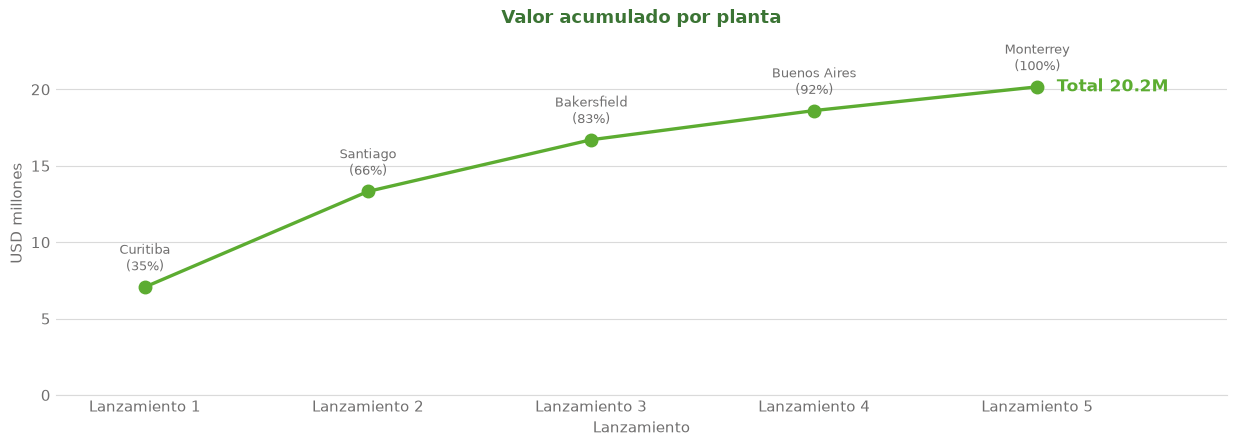

Lanzamiento,Planta añadida,Ahorro anual,% valor total,Tipos de caja activos,Valor incremental
Lanzamiento 1,Curitiba,"7,07M",35.0%,207,"7,07M"
Lanzamiento 2,Santiago,"13,32M",66.1%,161,"6,25M"
Lanzamiento 3,Bakersfield,"16,70M",82.8%,131,"3,38M"
Lanzamiento 4,Buenos Aires,"18,61M",92.3%,93,"1,91M"
Lanzamiento 5,Monterrey,"20,17M",100.0%,41,"1,55M"


In [7]:
v = valor.set_index("planta_id")
m = mig.set_index("planta")
comp_raw = pd.DataFrame({
    "skus_changed": m["skus_changed"],
    "new_boxes": m["box_types_new"],
    # volumen que NO puede quedarse en caja Actual (sin fit funcional)
    "pct_vol_must_move": 100.0 - m["pct_vol_functional"],
})
z = (comp_raw - comp_raw.mean()) / comp_raw.std(ddof=0).replace(0, 1)
complexity = z.sum(axis=1)
savings = v["savings"]
bubble = m["pack_spend_affected"].clip(lower=1)

pareto = pareto_mask(complexity.to_numpy(), savings.loc[complexity.index].to_numpy())
pilot_df = pd.DataFrame({
    "planta": [PLANT_LABELS[p] for p in complexity.index],
    "planta_id": list(complexity.index),
    "complexity": complexity.values,
    "savings": savings.loc[complexity.index].values,
    "bubble": bubble.loc[complexity.index].values,
    "pareto": pareto,
    "skus_changed": m["skus_changed"].values,
    "new_boxes": m["box_types_new"].values,
    "pct_vol_functional": m["pct_vol_functional"].values,
    "pct_vol_must_move": (100.0 - m["pct_vol_functional"]).values,
    "share_programme_pct": v["share_programme_pct"].loc[complexity.index].values,
}).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(7.5, 5.0))
sizes = 200 + 800 * (pilot_df["bubble"] / pilot_df["bubble"].max())
for i, r in pilot_df.iterrows():
    col = GREEN if r["pareto"] else LIGHT_GRAY
    ax.scatter(
        r["complexity"], r["savings"] / 1e6, s=float(sizes.iloc[i]),
        c=col, alpha=0.85, edgecolors=GREEN_DARK, lw=0.8,
    )
    ax.annotate(
        r["planta"], (r["complexity"], r["savings"] / 1e6),
        textcoords="offset points", xytext=(8, 4), fontsize=10,
        color=GREEN_DARK if r["pareto"] else GRAY,
        fontweight="bold" if r["pareto"] else "normal",
    )
pf = pilot_df[pilot_df["pareto"]].sort_values("complexity")
if len(pf) >= 2:
    ax.plot(pf["complexity"], pf["savings"] / 1e6, color=GREEN, ls="--", lw=1.2, alpha=0.7)
style_axes(ax, ylabel="Ahorro anual (USD millones)")
ax.set_xlabel("Complejidad de migración (z-score sum)", color=GRAY)
ax.set_title("Selección de piloto — valor vs complejidad")
ax.text(0.02, 0.95, "Verde = Pareto-eficiente", transform=ax.transAxes, color=GREEN, fontweight="bold", va="top")
plt.tight_layout()
plt.show()
fig.savefig(FIG_DIR / "260_pareto_piloto.png", dpi=140, bbox_inches="tight", facecolor="white")

pareto_plants = pilot_df[pilot_df["pareto"]].copy()
# Preferir Pareto con complejidad ≤ percentil 75 (piloto ejecutable) y máximo valor.
q75 = float(pilot_df["complexity"].quantile(0.75))
candidates = pareto_plants[pareto_plants["complexity"] <= q75]
if candidates.empty:
    candidates = pareto_plants
rec = candidates.sort_values("savings", ascending=False).iloc[0]
PILOT_ID = rec["planta_id"]
PILOT_LABEL = rec["planta"]
print(f"Piloto recomendado (Pareto + complejidad acotada): {PILOT_LABEL}")
print(
    f"  Ahorro USD {rec['savings']:,.0f} ({rec['share_programme_pct']:.1f}% del programa) · "
    f"SKUs chg={int(rec['skus_changed'])} · new boxes={int(rec['new_boxes'])} · "
    f"vol functional overlap={rec['pct_vol_functional']:.1f}%"
)
print(
    "Nota: Curitiba lidera valor absoluto; si complejidad alta es aceptable, "
    "también es Pareto y es Wave 1 del orden max-valor."
)
display(pilot_df.round(2))

# Curva de valor: orden por mayor impacto global (greedy = Curitiba primero).
# El piloto Pareto (Santiago) sigue siendo la recomendación operativa en Lectura/gates.
waves = waves_value.copy()
waves.to_csv(TAB_DIR / "260_rollout_waves.csv", index=False)
print("Guardado: outputs/tables/260_rollout_waves.csv")
print(
    "Rollout por impacto:",
    " → ".join(waves.loc[waves["wave"] > 0, "plant_label"].tolist()),
)

fig, ax = plt.subplots(figsize=(12.5, 4.6))
wdf = waves[waves["wave"] > 0]
ax.plot(
    wdf["wave"], wdf["annual_savings"] / 1e6,
    color=GREEN, marker="o", lw=2.4, ms=9, zorder=3,
)
for _, r in wdf.iterrows():
    label = PLANT_LABELS.get(r["plant_added"], r["plant_added"])
    ax.annotate(
        f"{label}\n({r['pct_total_value']:.0f}%)",
        (r["wave"], r["annual_savings"] / 1e6),
        textcoords="offset points", xytext=(0, 12), ha="center", fontsize=9, color=GRAY,
    )
total_m = float(wdf["annual_savings"].iloc[-1] / 1e6)
ax.annotate(
    f"Total {total_m:.1f}M",
    xy=(wdf["wave"].iloc[-1], total_m),
    xytext=(14, 0),
    textcoords="offset points",
    ha="left",
    va="center",
    fontsize=12,
    color=GREEN,
    fontweight="bold",
)
style_axes(ax, ylabel="USD millones")
ax.set_xlabel("Lanzamiento", color=GRAY)
ax.set_xticks(list(wdf["wave"]))
ax.set_xticklabels([f"Lanzamiento {int(w)}" for w in wdf["wave"]])
ax.set_xlim(0.6, float(wdf["wave"].iloc[-1]) + 0.85)
ax.set_ylim(0, total_m * 1.18)
ax.set_title("Valor acumulado por planta")
plt.tight_layout()
plt.show()
fig.savefig(FIG_DIR / "260_rollout_cumulative.png", dpi=140, bbox_inches="tight", facecolor="white")

css = (
    ".bp-wrap { background:#fff; color:#706F6F; font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',Helvetica,Arial,sans-serif; }"
    ".bp-title { color:#3B7434; font-weight:700; font-size:14px; margin:0 0 4px; }"
    ".bp-sub { color:#706F6F; font-size:11px; margin:0 0 12px; }"
    ".bp-table { border-collapse:collapse; width:100%; font-size:12px; }"
    ".bp-table th { text-transform:uppercase; letter-spacing:0.04em; border-bottom:1px solid #DADADA; padding:6px 8px; text-align:left; color:#3B7434; font-size:10px; }"
    ".bp-table td { border-bottom:1px solid #DADADA; padding:6px 8px; }"
    ".bp-table td.num { text-align:right; font-variant-numeric:tabular-nums; }"
    ".bp-table .delta { color:#5CAC31; font-weight:600; }"
)
trs = []
for _, r in waves[waves["wave"] > 0].iterrows():
    trs.append(
        f"<tr><td>Lanzamiento {int(r['wave'])}</td>"
        f"<td>{r['plant_label']}</td>"
        f"<td class='num delta'>{fmt_es(r['annual_savings']/1e6,2)}M</td>"
        f"<td class='num'>{r['pct_total_value']:.1f}%</td>"
        f"<td class='num'>{int(r['active_box_types'])}</td>"
        f"<td class='num'>{fmt_es(r['incremental_value']/1e6,2)}M</td></tr>"
    )
html = (
    f"<style>{css}</style><div class='bp-wrap'>"
    "<p class='bp-title'>C. Rollout por mayor impacto global</p>"
    "<p class='bp-sub'>Orden greedy: en cada lanzamiento se agrega la planta con mayor valor marginal. Catálogo = unión temporal.</p>"
    "<table class='bp-table'><thead><tr>"
    "<th>Lanzamiento</th><th>Planta añadida</th><th>Ahorro anual</th>"
    "<th>% valor total</th><th>Tipos de caja activos</th><th>Valor incremental</th>"
    "</tr></thead><tbody>"
    + "".join(trs)
    + "</tbody></table></div>"
)
display(HTML(html))


## 5. Envelopes de payback — ¿cuánto costo de migración tolera el proyecto?

Sin cifras reales de tooling/write-off, el techo útil es el ahorro anual × (T/12) meses.

Escenarios ilustrativos Year-1 (Low/Med/High = 15% / 35% / 60% del ahorro anual como costo one-time) — **supuestos**, no inputs de Operations.


In [8]:
pay_rows = []
for _, r in valor.iterrows():
    sav = r["savings"]
    pay_rows.append({
        "planta": r["planta"],
        "planta_id": r["planta_id"],
        "annual_savings": sav,
        "max_cost_12m": sav * 1.0,
        "max_cost_18m": sav * 1.5,
        "max_cost_24m": sav * 2.0,
        "y1_net_low_15pct": sav - 0.15 * sav,
        "y1_net_med_35pct": sav - 0.35 * sav,
        "y1_net_high_60pct": sav - 0.60 * sav,
    })
payback = pd.DataFrame(pay_rows)
payback.to_csv(TAB_DIR / "260_payback_envelopes.csv", index=False)
print("Guardado: outputs/tables/260_payback_envelopes.csv")

css = (
    ".bp-wrap { background:#fff; color:#706F6F; font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',Helvetica,Arial,sans-serif; }"
    ".bp-title { color:#3B7434; font-weight:700; font-size:14px; margin:0 0 4px; }"
    ".bp-sub { color:#706F6F; font-size:11px; margin:0 0 12px; }"
    ".bp-table { border-collapse:collapse; width:100%; font-size:12px; }"
    ".bp-table th { text-transform:uppercase; letter-spacing:0.04em; border-bottom:1px solid #DADADA; padding:6px 8px; text-align:left; color:#3B7434; font-size:10px; }"
    ".bp-table td { border-bottom:1px solid #DADADA; padding:6px 8px; }"
    ".bp-table td.num { text-align:right; font-variant-numeric:tabular-nums; }"
    ".bp-table .delta { color:#5CAC31; font-weight:600; }"
)
trs = []
for _, r in payback.iterrows():
    trs.append(
        f"<tr><td>{r['planta']}</td>"
        f"<td class='num delta'>{fmt_es(r['annual_savings']/1e6,2)}M</td>"
        f"<td class='num'>{fmt_es(r['max_cost_12m']/1e6,2)}M</td>"
        f"<td class='num'>{fmt_es(r['max_cost_18m']/1e6,2)}M</td>"
        f"<td class='num'>{fmt_es(r['max_cost_24m']/1e6,2)}M</td>"
        f"<td class='num'>{fmt_es(r['y1_net_med_35pct']/1e6,2)}M</td></tr>"
    )
html = (
    f"<style>{css}</style><div class='bp-wrap'>"
    "<p class='bp-title'>E. Máximo costo one-time tolerable</p>"
    "<p class='bp-sub'>Y1 neto asume costo de migración = 35% del ahorro anual — escenario medio ilustrativo.</p>"
    "<table class='bp-table'><thead><tr>"
    "<th>Plant</th><th>Annual savings</th><th>Max 12-mo</th><th>Max 18-mo</th><th>Max 24-mo</th><th>Y1 net @35%</th>"
    "</tr></thead><tbody>"
    + "".join(trs)
    + "</tbody></table></div>"
)
display(HTML(html))


Guardado: outputs/tables/260_payback_envelopes.csv


Plant,Annual savings,Max 12-mo,Max 18-mo,Max 24-mo,Y1 net @35%
Curitiba,"7,07M","7,07M","10,60M","14,13M","4,59M"
Santiago,"6,18M","6,18M","9,27M","12,36M","4,02M"
Buenos Aires,"1,91M","1,91M","2,87M","3,82M","1,24M"
Bakersfield,"3,33M","3,33M","4,99M","6,65M","2,16M"
Monterrey,"1,55M","1,55M","2,33M","3,11M","1,01M"


## 6. Gate scorecard — qué debe probar el piloto

Baselines económicos del modelo (utilización, flete/unidad, costo caja/unidad). Umbrales de Quality / Production / Service los aprueba Operations — aquí quedan como **gates a definir**, no como datos inventados.

Resultados posibles del piloto: **Scale · Rework · Stop**.


In [9]:
pid = PILOT_ID
vol_p = float(ops[f"volumen_producto_planta_{pid}"].sum())
a, b = m_act[pid], m_prop[pid]
sav_p = float(valor.loc[valor.planta_id == pid, "savings"].iloc[0])
kpis = [
    ("Economics", "Realized savings vs model", f"Target ≥ 80% of {fmt_usd(sav_p)}", "Ops finance"),
    ("Logistics", "Units per pallet / pallets shipped", f"Model util {b['util_pallet_pct']:.1f}% (vs {a['util_pallet_pct']:.1f}% actual)", "Model baseline"),
    ("Logistics", "Freight per unit", f"Model ${b['costo_envio']/vol_p:.4f} / unit", "Model baseline"),
    ("Packaging", "Box cost per unit", f"Model ${b['costo_cajas']/vol_p:.4f} / unit", "Model baseline"),
    ("Quality", "Damage / compression / deformation", "≤ baseline Actual (threshold TBD Ops/QA)", "Ops approve"),
    ("Production", "Line throughput & stoppages", "No material regression vs baseline (TBD)", "Ops approve"),
    ("Service", "Fill rate / delays / exceptions", "≥ baseline service level (TBD)", "Ops approve"),
    ("Complexity", "Manual assignment exceptions", "≤ agreed cap during pilot window", "Ops approve"),
]

css = (
    ".cert-wrap { background:#000; color:#DADADA; font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',Helvetica,Arial,sans-serif; padding:14px; }"
    ".cert-title { color:#5CAC31; font-weight:700; font-size:14px; margin:0 0 4px; }"
    ".cert-sub { color:#9A9A9A; font-size:11px; margin:0 0 12px; }"
    ".cert-table { border-collapse:collapse; width:100%; font-size:12px; }"
    ".cert-table th { text-transform:uppercase; letter-spacing:0.04em; border-bottom:1px solid #2A2A2A; padding:6px 8px; text-align:left; color:#9A9A9A; font-size:10px; }"
    ".cert-table td { border-bottom:1px solid #2A2A2A; padding:6px 8px; vertical-align:top; }"
    ".cert-table .optimal { color:#5CAC31; font-weight:700; }"
    ".cert-table .feasible { color:#E6B84D; font-weight:600; }"
    ".gate-box { display:flex; gap:12px; margin-top:14px; }"
    ".gate-pill { flex:1; border:1px solid #2A2A2A; padding:10px; text-align:center; }"
    ".gate-pill .g { font-weight:700; font-size:13px; }"
)
trs = []
for d, k, t, s in kpis:
    cls = "optimal" if s == "Model baseline" else "feasible"
    trs.append(f"<tr><td>{d}</td><td>{k}</td><td>{t}</td><td class='{cls}'>{s}</td></tr>")
html = (
    f"<style>{css}</style><div class='cert-wrap'>"
    f"<p class='cert-title'>F. Pilot gate scorecard — {PILOT_LABEL}</p>"
    "<p class='cert-sub'>Baselines del modelo listos. Umbrales Ops/QA requieren aprobación antes del go-live.</p>"
    "<table class='cert-table'><thead><tr>"
    "<th>Dimension</th><th>Pilot KPI</th><th>Baseline / target</th><th>Owner</th>"
    "</tr></thead><tbody>"
    + "".join(trs)
    + "</tbody></table>"
    "<div class='gate-box'>"
    "<div class='gate-pill'><div class='g' style='color:#5CAC31'>SCALE</div>"
    "<div style='font-size:11px;color:#9A9A9A;margin-top:4px'>Gates verdes → Wave 2</div></div>"
    "<div class='gate-pill'><div class='g' style='color:#E6B84D'>REWORK</div>"
    "<div style='font-size:11px;color:#9A9A9A;margin-top:4px'>Ajuste de asignación / catálogo</div></div>"
    "<div class='gate-pill'><div class='g' style='color:#DADADA'>STOP</div>"
    "<div style='font-size:11px;color:#9A9A9A;margin-top:4px'>Regresión material en quality/service</div></div>"
    "</div></div>"
)
display(HTML(html))

gates = pd.DataFrame(kpis, columns=["dimension", "kpi", "baseline_or_target", "owner"])
gates.to_csv(TAB_DIR / "260_gate_scorecard.csv", index=False)


Dimension,Pilot KPI,Baseline / target,Owner
Economics,Realized savings vs model,Target ≥ 80% of USD 6.179.124,Ops finance
Logistics,Units per pallet / pallets shipped,Model util 94.8% (vs 83.4% actual),Model baseline
Logistics,Freight per unit,Model $2.6354 / unit,Model baseline
Packaging,Box cost per unit,Model $0.4320 / unit,Model baseline
Quality,Damage / compression / deformation,≤ baseline Actual (threshold TBD Ops/QA),Ops approve
Production,Line throughput & stoppages,No material regression vs baseline (TBD),Ops approve
Service,Fill rate / delays / exceptions,≥ baseline service level (TBD),Ops approve
Complexity,Manual assignment exceptions,≤ agreed cap during pilot window,Ops approve


## 7. Sensibilidad Mark16 (demand-aware)

¿Cambia el ranking de valor por planta si en lugar del protocolo Mark17 usamos la Óptima demand-aware (Mark16)?


In [10]:
eval_m16 = evaluar_kaggle(mark16_sens, ops)
m_m16 = metricas_por_planta(eval_m16)
AHORRO_M16 = COSTO_BASELINE - eval_m16["total"]
SCORE_M16 = score_publico(eval_m16["total"], COSTO_BASELINE)

sens = []
for p in PLANT_ORDER:
    sav17 = m_act[p]["costo_total"] - m_prop[p]["costo_total"]
    sav16 = m_act[p]["costo_total"] - m_m16[p]["costo_total"]
    sens.append({
        "planta": PLANT_LABELS[p],
        "savings_mark17": sav17,
        "savings_mark16": sav16,
        "delta_m16_vs_m17": sav16 - sav17,
    })
sens = pd.DataFrame(sens)
sens["rank_mark17"] = sens["savings_mark17"].rank(ascending=False).astype(int)
sens["rank_mark16"] = sens["savings_mark16"].rank(ascending=False).astype(int)
sens.to_csv(TAB_DIR / "260_sensibilidad_mark16.csv", index=False)

top17 = sens.sort_values("savings_mark17", ascending=False).iloc[0]["planta"]
top16 = sens.sort_values("savings_mark16", ascending=False).iloc[0]["planta"]
print(f"Mark16 total: USD {eval_m16['total']:,.0f}  ahorro={AHORRO_M16:,.0f}  score={SCORE_M16:+.5f}")
print(f"Planta #1 Mark17 (protocolo): {top17}  |  Mark16 (demand-aware): {top16}  |  flip={'SÍ' if top17 != top16 else 'NO'}")
display(sens.round(0))


Mark16 total: USD 188,079,384  ahorro=21,155,710  score=+10.11098
Planta #1 Mark17 (protocolo): Curitiba  |  Mark16 (demand-aware): Curitiba  |  flip=NO


,planta,savings_mark17,savings_mark16,delta_m16_vs_m17,rank_mark17,rank_mark16
0,Curitiba,7067223.0,7541994.0,474771.0,1,1
1,Santiago,6179124.0,6383755.0,204631.0,2,2
2,Buenos Aires,1910803.0,2152179.0,241376.0,4,4
3,Bakersfield,3326897.0,3369264.0,42367.0,3,3
4,Monterrey,1553098.0,1708519.0,155421.0,5,5


## Lectura


In [11]:
vr = valor.loc[valor["planta_id"] == PILOT_ID].iloc[0]
mr = mig.loc[mig["planta"] == PILOT_ID].iloc[0]
pr = payback.loc[payback["planta_id"] == PILOT_ID].iloc[0]
indep_msg = (
    "Los ahorros 1-planta son casi aditivos bajo reglas Kaggle (tiers por planta): "
    f"suma singles = {fmt_usd(sum_singles)} vs full = {fmt_usd(full_sav)} "
    f"(gap {fmt_usd(coupling_gap)}, {100*coupling_gap/full_sav:+.2f}%). "
    "El catálogo se acopla por geometría global, pero el valor del rollout parcial se preserva."
)

print("=" * 72)
print("RECOMENDACIÓN DE PILOTO")
print("=" * 72)
print(
    f"Begin with {PILOT_LABEL}: it captures {fmt_usd(vr['savings'])} annually "
    f"({vr['share_programme_pct']:.1f}% of total programme value), "
    f"requires {int(mr['box_types_new'])} new box designs, "
    f"{int(mr['skus_changed'])} SKU reassignments "
    f"({fmt_usd(vr['savings_per_sku_changed'])} per changed SKU), "
    f"and {mr['pct_vol_functional']:.1f}% of plant volume can temporarily keep a functionally valid Actual box. "
    f"Max one-time migration cost for 12-month payback: {fmt_usd(pr['max_cost_12m'])}. "
    f"Full rollout remains conditional on Gate 3 operating results."
)
print()
print("Rollout por impacto (valor acumulado):")
for _, r in waves[waves["wave"] > 0].iterrows():
    tag = "Wave 1" if int(r["wave"]) == 1 else f"Wave {int(r['wave'])}"
    print(
        f"  {tag}: +{PLANT_LABELS.get(r['plant_added'], r['plant_added'])} → "
        f"{fmt_usd(r['annual_savings'])} ({r['pct_total_value']:.1f}%)  "
        f"Δ {fmt_usd(r['incremental_value'])}"
    )
print(f"(Piloto operativo recomendado por Pareto: {PILOT_LABEL})")
print()
print(indep_msg)
print()
print("Pareto plants:", ", ".join(pilot_df.loc[pilot_df["pareto"], "planta"].tolist()))


RECOMENDACIÓN DE PILOTO
Begin with Santiago: it captures USD 6.179.124 annually (30.8% of total programme value), requires 26 new box designs, 173 SKU reassignments (USD 35.717 per changed SKU), and 66.8% of plant volume can temporarily keep a functionally valid Actual box. Max one-time migration cost for 12-month payback: USD 6.179.124. Full rollout remains conditional on Gate 3 operating results.

Rollout por impacto (valor acumulado):
  Wave 1: +Curitiba → USD 7.067.223 (35.0%)  Δ USD 7.067.223
  Wave 2: +Santiago → USD 13.321.882 (66.1%)  Δ USD 6.254.659
  Wave 3: +Bakersfield → USD 16.702.422 (82.8%)  Δ USD 3.380.540
  Wave 4: +Buenos Aires → USD 18.613.225 (92.3%)  Δ USD 1.910.803
  Wave 5: +Monterrey → USD 20.166.323 (100.0%)  Δ USD 1.553.098
(Piloto operativo recomendado por Pareto: Santiago)

Los ahorros 1-planta son casi aditivos bajo reglas Kaggle (tiers por planta): suma singles = USD 20.166.323 vs full = USD 20.166.323 (gap USD -0, -0.00%). El catálogo se acopla por geomet